# Does inverting the DAPI image sharpen its stitching registration?

`test_stitching.ipynb`'s real run on `BC555_sample_05` found beads register
more precisely than DAPI (near-zero diagonal loop-closure residual for
beads vs. a systematically higher one for DAPI, in every corner of every
neighbourhood) -- attributed to beads being sharp, localized point sources,
while DAPI's nuclear signal is broad/diffuse, so phase correlation responds
more weakly to a small true position error.

**Hypothesis under test** (the user's): invert the DAPI image
(`2**16 - I`) and remove its new minimum so the background sits near zero.
Nuclei (the raw image's bright blobs) become the new *background*; the
inter-nuclear gaps (raw background) become the new bright regions. If those
gaps are thin/sharp relative to the smooth nuclear blobs, the inverted
image's dominant spatial content might resemble beads' point-like sharpness
more than DAPI's own diffuse blobs.

**A caveat worth stating up front, not discovering by surprise from a null
result**: this repo's registration primitive is
`skimage.registration.phase_cross_correlation` (`alignment.phase_drift`),
a *normalized* cross-power-spectrum method, and `overlap_correlation`'s
own quality score is a Pearson correlation. Both are, in the noiseless
case, invariant (up to an irrelevant sign flip) to a purely affine
transform of one image's intensities -- `2**16 - I` followed by an
additive shift is exactly that, so in principle it should not change
registration at all. The one real, non-affine step in the actual pipeline
is `alignment.remove_hot_pixels` (called inside both `phase_drift` and
`overlap_correlation`): its hot-pixel test is `img > ratio * local_median`,
a *multiplicative* threshold, so it responds differently depending on
where the background sits relative to zero -- which is exactly what the
"remove the minimum value" step changes. So any real effect found here is
most likely mediated by that hot-pixel step, not by phase correlation
itself becoming "sharper" in some fundamental sense -- worth keeping in
mind when interpreting the plots below.

**Two datasets** -- `BC555_sample_05/epi` and `BC555_sample_05/disk` (same
sample/tissue, two microscopes): `disk`'s beads are known far dimmer/
sparser than `epi`'s (`test_bead_intensity_and_count_epi_vs_disk.ipynb`),
so it's the strongest real test of whether DAPI inversion could ever help
-- if it helps anywhere, it should help most where beads are weakest.

**Three tests, real `cells`-round frames only (beads = frame 0, DAPI =
405nm z-index 3, both real HAL conventions this repo already relies on
elsewhere)**:

1. **Self-shift** (Sections 5-6): ONE real image per channel, correlated
   against a synthetically-shifted copy of ITSELF (not a different real
   FOV) -- correlation is exactly 1.0 at shift=0 by construction, and its
   decay away from 0 measures that channel's own spatial content
   sharpness in isolation, free of any confound from comparing two
   independently-acquired images. This is the cleanest, most literal test
   of "the correlation function has a stronger response to small position
   changes."
2. **Cross-tile** (Sections 7-8): correlation between a REAL anchor/
   neighbour tile pair vs. small synthetic shifts around their real
   measured alignment -- both a single real edge (no averaging, so its
   actual shape is visible) and the mean +/- std over
   `N_EDGES_FOR_SHIFT_CURVE` edges. Correlation here is NOT expected to
   reach 1.0 even at the true alignment -- two different real
   acquisitions never correlate perfectly (independent noise, no two
   exposures of the same physical spot are shot-noise-identical) -- this
   test is about registration PRECISION (how much correlation drops for a
   small position error), not about achievable correlation magnitude.
3. **Practical** (Sections 9-10): re-run `camera_rotation.
   sample_neighbor_correspondences` over a real sample of the grid, for
   all three channels, and compare `overlap_correlation` evaluated AT each
   edge's own achieved registration -- a real Pearson-correlation
   confidence score, not `NeighborCorrespondence.error`
   (`phase_cross_correlation`'s own `error` field turns out to saturate
   near 1.0 for essentially any real 16-bit input under skimage's default
   `normalization="phase"` -- confirmed on a first pass at this notebook,
   see Section 9's own markdown -- so it's kept in the cache for the
   record but not used as the actual comparison here).

Follows `NOTEBOOK_GUIDELINES.md`: calculation cells cached under
`analysis/cache/test_dapi_inversion/` (one subfolder per dataset,
implicitly via each dataset's own `analysis/` tree), skip recomputation
when a valid cache exists, `ProgressReporter` progress, explicit plot font
sizes, every displayed figure also saved to `analysis/figures/`.

## 1 — Setup

In [1]:
import os
import sys
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import shift as ndi_shift
from scipy.spatial import KDTree

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/tests/fov_stitching/01_test_stitching.ipynb.
MERCI_DIR = Path(os.getcwd()).parent.parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import load_positions, read_image_frames
from MERci.common.experiment_info import load_experiment_info, resolve_sample_identity, positions_file_tag
from MERci.acquisition.configs    import (
    find_frame_table_for_hal_config, get_camera_pixel_size_um, get_camera_frame_size,
    get_all_color_frame_indices,
)
from MERci.acquisition.positions       import find_grid_neighbor
from MERci.acquisition.camera_rotation import (
    apply_microscope_orientation, crop_overlap, register_neighbor_pair, overlap_correlation,
)
from MERci.acquisition.alignment  import remove_hot_pixels, phase_drift
from MERci.acquisition.merlin_config import load_microscope_orientation
from MERci.progress_display       import ProgressReporter
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "test_dapi_inversion"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci


## 2 — Parameters

In [2]:
# Same sample test_stitching.ipynb already established a beads-vs-DAPI
# residual gap on, both microscopes -- disk's beads are known far weaker
# (test_bead_intensity_and_count_epi_vs_disk.ipynb), the strongest real
# test of whether DAPI inversion could ever help.
DATASETS = [
    ("epi",  "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi"),
    ("disk", "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk"),
]
IMAGE_SUFFIX = ".zarr"

BEAD_FRAME_INDEX = 0     # HAL's own bead/fiducial frame convention (cells round)
DAPI_COLOR_NM    = 405.0
DAPI_Z_INDEX     = 3     # same z-index test_stitching.ipynb uses

CHANNELS = ("beads", "dapi_raw", "dapi_inv")
CHANNEL_COLORS = {"beads": "tab:blue", "dapi_raw": "tab:orange", "dapi_inv": "tab:green"}

TOLERANCE_FRACTION = 0.25   # same default as find_grid_neighbor
UPSAMPLE_FACTOR     = 10    # sub-pixel registration precision (1/UPSAMPLE_FACTOR px)
SEED = 0

# Sections 5-8: synthetic sub-pixel shift sweep, shared by both the
# self-shift and cross-tile mechanistic tests.
SHIFT_RANGE_PX = np.arange(-3.0, 3.01, 0.25)
N_EDGES_FOR_SHIFT_CURVE = 8   # cross-tile test only

# Section 9 (practical): real anchors sampled across the grid, same primitive
# and similar sample size to test_stitching.ipynb's own 3-neighbourhood run
# (27 edges) but spread across the whole grid rather than 3 local blocks.
# Kept modest -- each channel's own pass holds every FOV it touches
# (~2304x2304 or ~2304x2304 uint16, ~10MB/frame) in memory simultaneously.
N_ANCHORS = 20

FORCE_RECOMPUTE = False   # set True to re-register even if a cache already exists

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10

print(f"Datasets: {[label for label, _ in DATASETS]}")

Datasets: ['epi', 'disk']


## 3 — Resolve the cells round + FOV geometry (per dataset)

Same logic as `test_stitching.ipynb`'s own multi-dataset
`resolve_dataset_geometry`, wrapped so it runs once per dataset in
`DATASETS`.

In [3]:
def resolve_dataset_geometry(dataset_label, dataset_dir):
    sample_dir = Path(dataset_dir)
    sample_name, imaging_dir = resolve_sample_identity(sample_dir / "MERci")
    positions_tag = positions_file_tag(sample_name, imaging_dir)

    info       = load_experiment_info(sample_dir / "metadata" / "experiment_info.yaml")
    microscope = info.microscope

    config = ExperimentConfig(
        data_dir       = sample_dir / "data",
        metadata_dir   = sample_dir / "metadata",
        analysis_dir   = sample_dir / "analysis",
        settings_dir   = sample_dir / "settings",
        round_info_csv = sample_dir / "metadata" / "round_info.csv",
        positions_txt  = sample_dir / "positions" / f"positions_{positions_tag}.txt",
        image_suffix   = IMAGE_SUFFIX,
        microscope     = microscope,
    )
    meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                    image_suffix=config.image_suffix)

    def resolve_round_id(meta, imaging_type):
        for rid in meta.valid_round_ids():
            if any((s.imaging_type or "").strip().lower() == imaging_type.strip().lower()
                   for s in meta.series_for_round(rid)):
                return rid
        raise ValueError(f"No round found with imaging_type={imaging_type!r}")

    cells_round_id = resolve_round_id(meta, "cells")
    if not meta.round_fully_written(cells_round_id):
        print(f"WARNING [{dataset_label}]: cells round {cells_round_id} is not yet fully written on disk -- "
              f"some FOVs sampled below may be missing.")

    cells_series = next(s for s in meta.series_for_round(cells_round_id) if s.hal_config)
    hal_path     = Path(config.settings_dir) / cells_series.hal_config
    ft_path      = find_frame_table_for_hal_config(hal_path, config.metadata_dir)
    if ft_path is None or not ft_path.exists():
        raise FileNotFoundError(f"No frame table found for the cells round (hal_config={hal_path}).")
    frame_table = pd.read_csv(ft_path, index_col=0)

    dapi_frame_indices = get_all_color_frame_indices(frame_table, DAPI_COLOR_NM)
    if DAPI_Z_INDEX >= len(dapi_frame_indices):
        raise ValueError(
            f"[{dataset_label}] DAPI_Z_INDEX={DAPI_Z_INDEX} out of range -- {DAPI_COLOR_NM:.0f}nm only has "
            f"{len(dapi_frame_indices)} z-plane(s) in this frame table.")
    dapi_frame_index = dapi_frame_indices[DAPI_Z_INDEX]

    pixel_size_um      = get_camera_pixel_size_um(microscope)
    frame_width_px, _  = get_camera_frame_size(microscope)
    frame_width_um     = frame_width_px * pixel_size_um

    full_positions = load_positions(config.positions_txt)
    cells_fov_ids  = sorted(f for f in full_positions if f in meta.fovs)

    coords_arr = np.array([full_positions[f] for f in cells_fov_ids], dtype=float)
    nn_dist, _ = KDTree(coords_arr).query(coords_arr, k=2)
    step_size_um     = float(np.median(nn_dist[:, 1]))
    overlap_fraction = max(0.0, 1.0 - step_size_um / frame_width_um)

    orientation = load_microscope_orientation(microscope, MERCI_DIR / "data" / "configs" / "merlin" / "microscope")
    orient_transpose       = bool(orientation.get("transpose", False))
    orient_flip_horizontal = bool(orientation.get("flip_horizontal", False))
    orient_flip_vertical   = bool(orientation.get("flip_vertical", False))

    cache_dir   = config.analysis_dir / "cache" / NOTEBOOK_NAME
    figures_dir = get_merci_figures_dir(sample_dir, "tests", NOTEBOOK_NAME, subfolder="fov_stitching")
    cache_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)

    print(f"[{dataset_label}] microscope={microscope}  cells_round={cells_round_id}  "
          f"bead_frame={BEAD_FRAME_INDEX}  dapi_frame={dapi_frame_index}  "
          f"pixel_size_um={pixel_size_um}  step_size_um={step_size_um:.3f}  "
          f"overlap_fraction={overlap_fraction:.3f}  n_fovs={len(cells_fov_ids)}")
    print(f"[{dataset_label}] orientation: transpose={orient_transpose}  "
          f"flip_horizontal={orient_flip_horizontal}  flip_vertical={orient_flip_vertical}")

    return {
        "dataset_label": dataset_label, "sample_dir": sample_dir, "config": config,
        "cells_series": cells_series, "dapi_frame_index": dapi_frame_index,
        "pixel_size_um": pixel_size_um, "frame_width_um": frame_width_um,
        "full_positions": full_positions, "cells_fov_ids": cells_fov_ids,
        "step_size_um": step_size_um, "overlap_fraction": overlap_fraction,
        "orient_transpose": orient_transpose, "orient_flip_horizontal": orient_flip_horizontal,
        "orient_flip_vertical": orient_flip_vertical,
        "cache_dir": cache_dir, "figures_dir": figures_dir,
    }

## 4 — Per-dataset 3-channel frame loader

`dapi_inv` is computed from the SAME raw DAPI read as `dapi_raw` (one file
read serves both channels), applying the hypothesis literally: `2**16 - I`,
then subtract the result's own minimum so the background sits at 0 --
exactly the two steps the user described.

Memory note: the raw-frame cache returned here only holds the two REAL
reads (`beads`, `dapi_raw`, both `uint16`, ~10MB/frame each) -- `dapi_inv`
is a cheap elementwise derivative of `dapi_raw`, recomputed on demand
rather than cached a third time (caching all three per FOV, one being a
much larger `float64`, is what OOM-killed an earlier version of this
notebook -- see this notebook's own `prompt_history/` entries).

In [4]:
def make_channel_loaders(dataset_geo):
    """Returns (load_channel_frames, load_frame_for_channel, raw_cache) for
    ONE dataset -- raw_cache is exposed so callers can .clear() it between
    channels/datasets to bound memory."""
    cells_series, config = dataset_geo["cells_series"], dataset_geo["config"]
    dapi_frame_index = dataset_geo["dapi_frame_index"]
    ot  = dataset_geo["orient_transpose"]
    ofh = dataset_geo["orient_flip_horizontal"]
    ofv = dataset_geo["orient_flip_vertical"]

    raw_cache = {}   # {fov_id: (bead_raw, dapi_raw)}, oriented uint16

    def _get_raw(fov_id):
        if fov_id not in raw_cache:
            path = cells_series.resolve_path(fov_id, config.image_suffix)
            bead_raw, dapi_raw = read_image_frames(
                path, [BEAD_FRAME_INDEX, dapi_frame_index],
                frame_width=config.frame_width, frame_height=config.frame_height,
            )
            bead_raw = apply_microscope_orientation(bead_raw, ot, ofh, ofv)
            dapi_raw = apply_microscope_orientation(dapi_raw, ot, ofh, ofv)
            raw_cache[fov_id] = (bead_raw, dapi_raw)
        return raw_cache[fov_id]

    def _invert_dapi(dapi_raw):
        # float64 only transiently, for the subtraction -- the result fits
        # comfortably in uint16 (raw DAPI's own max is far below 65535, so
        # 65536-raw stays in range even before the min-subtraction), and
        # storing it as uint16 rather than float32/float64 matters: this
        # array is what sample_neighbor_correspondences's own internal
        # per-call cache stores per touched FOV, and a float32 copy (double
        # a uint16 frame's size) is what pushed disk's dapi_inv channel over
        # this session's own memory limit on an earlier run (see this
        # notebook's own prompt_history/ entries).
        dapi_inv = 2.0 ** 16 - dapi_raw.astype(np.float64)   # invert
        dapi_inv -= dapi_inv.min()                            # background -> 0
        return np.clip(np.round(dapi_inv), 0, 65535).astype(np.uint16)

    def load_channel_frames(fov_id):
        """{"beads":, "dapi_raw":, "dapi_inv":} for one FOV -- used only where
        all three are wanted together (e.g. the sanity-check picture);
        per-channel loops elsewhere use load_frame_for_channel instead."""
        bead_raw, dapi_raw = _get_raw(fov_id)
        return {"beads": bead_raw, "dapi_raw": dapi_raw, "dapi_inv": _invert_dapi(dapi_raw)}

    def load_frame_for_channel(channel):
        def _load(fov_id):
            bead_raw, dapi_raw = _get_raw(fov_id)
            if channel == "beads":
                return bead_raw
            if channel == "dapi_raw":
                return dapi_raw
            return _invert_dapi(dapi_raw)
        return _load

    return load_channel_frames, load_frame_for_channel, raw_cache

## 5 — Self-shift test + sanity-check picture (calculation)

In [5]:
def compute_self_shift_curve(dataset_geo, load_frame_for_channel):
    """ONE real FOV per channel, correlated against a synthetic shift of
    ITSELF along one axis (columns) -- correlation(shift=0) is exactly 1.0
    by construction; its decay away from 0 is that channel's own spatial
    content sharpness, free of any real-pair confound (independent noise,
    imperfect registration, ...)."""
    cache_csv = dataset_geo["cache_dir"] / "self_shift_curve.csv"
    if not FORCE_RECOMPUTE and cache_csv.exists():
        df = pd.read_csv(cache_csv)
        print(f"[{dataset_geo['dataset_label']}] Loaded cached self-shift curve from {cache_csv}")
        return df

    fov_id = dataset_geo["cells_fov_ids"][len(dataset_geo["cells_fov_ids"]) // 2]
    rows = []
    for channel in CHANNELS:
        img = remove_hot_pixels(load_frame_for_channel(channel)(fov_id)).astype(np.float64)
        for shift_px in SHIFT_RANGE_PX:
            shifted = ndi_shift(img, shift=(0.0, float(shift_px)), order=1, mode="nearest")
            corr = float(np.corrcoef(img.ravel(), shifted.ravel())[0, 1])
            rows.append({"fov_id": fov_id, "channel": channel, "shift_px": float(shift_px), "correlation": corr})

    df = pd.DataFrame(rows)
    df.to_csv(cache_csv, index=False)
    print(f"[{dataset_geo['dataset_label']}] Saved self-shift curve (FOV {fov_id}) to {cache_csv}")
    return df


RESULTS = {}
for dataset_label, dataset_dir in DATASETS:
    print(f"\n=== {dataset_label} ({dataset_dir}) ===")
    dataset_geo = resolve_dataset_geometry(dataset_label, dataset_dir)
    load_channel_frames, load_frame_for_channel, raw_cache = make_channel_loaders(dataset_geo)

    self_shift_df = compute_self_shift_curve(dataset_geo, load_frame_for_channel)

    RESULTS[dataset_label] = {
        "dataset_geo": dataset_geo, "load_channel_frames": load_channel_frames,
        "load_frame_for_channel": load_frame_for_channel, "raw_cache": raw_cache,
        "self_shift_df": self_shift_df,
    }

print(f"\nDatasets resolved: {list(RESULTS.keys())}")


=== epi (/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi) ===
[epi] microscope=MF3  cells_round=1  bead_frame=0  dapi_frame=4  pixel_size_um=0.108  step_size_um=199.066  overlap_fraction=0.100  n_fovs=476
[epi] orientation: transpose=True  flip_horizontal=False  flip_vertical=True
[epi] Loaded cached self-shift curve from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_dapi_inversion/self_shift_curve.csv

=== disk (/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk) ===


[disk] microscope=ST2  cells_round=1  bead_frame=0  dapi_frame=4  pixel_size_um=0.0878  step_size_um=182.062  overlap_fraction=0.100  n_fovs=603
[disk] orientation: transpose=True  flip_horizontal=True  flip_vertical=False
[disk] Loaded cached self-shift curve from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_dapi_inversion/self_shift_curve.csv

Datasets resolved: ['epi', 'disk']


### Sanity-check picture: raw vs. inverted DAPI, one real FOV per dataset

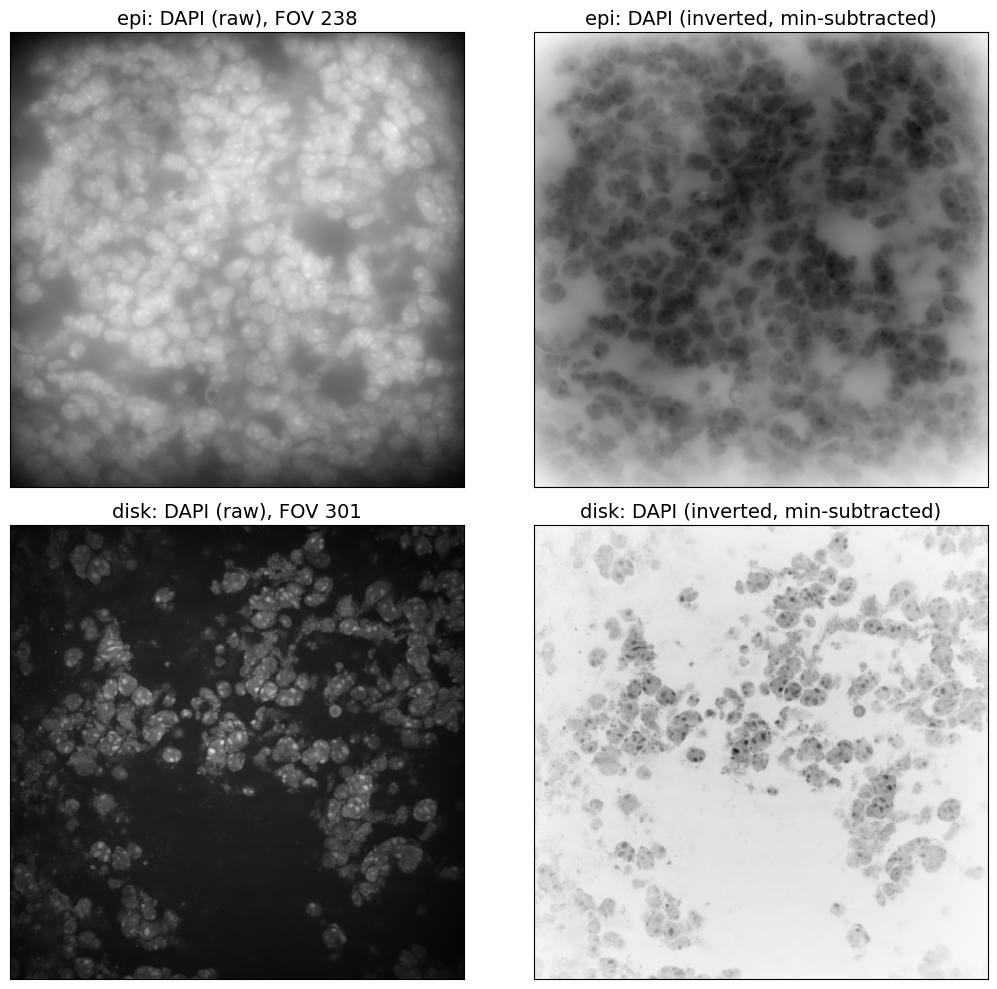

In [6]:
fig, axes = plt.subplots(len(DATASETS), 2, figsize=(11, 5 * len(DATASETS)), squeeze=False)
for row, (dataset_label, R) in enumerate(RESULTS.items()):
    dataset_geo = R["dataset_geo"]
    sample_fov = int(R["self_shift_df"]["fov_id"].iloc[0])
    sample = R["load_channel_frames"](sample_fov)
    axes[row, 0].imshow(sample["dapi_raw"], cmap="gray")
    axes[row, 0].set_title(f"{dataset_label}: DAPI (raw), FOV {sample_fov}", fontsize=PLOT_TITLE_FONTSIZE)
    axes[row, 1].imshow(sample["dapi_inv"], cmap="gray")
    axes[row, 1].set_title(f"{dataset_label}: DAPI (inverted, min-subtracted)", fontsize=PLOT_TITLE_FONTSIZE)
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fig.savefig(RESULTS["epi"]["dataset_geo"]["figures_dir"] / f"{NOTEBOOK_NAME}.raw_vs_inverted_example.png", dpi=150)
plt.show()

## 6 — Self-shift curves (display)

If this notebook's machinery is doing what it's supposed to, every
channel's curve MUST pass through `correlation=1.0` at `shift_px=0`
(comparing an image to an unshifted copy of itself) -- if that's not true,
something in the plotting/caching is broken, not the underlying
hypothesis.

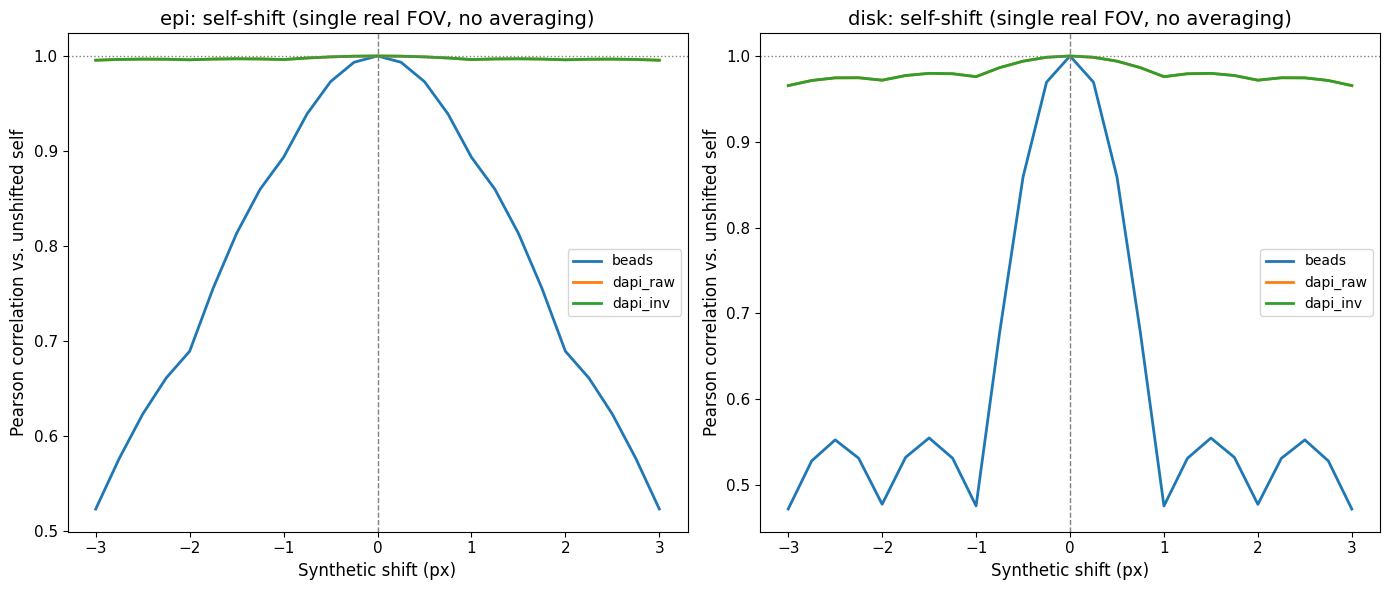

Sanity check -- correlation at shift=0 (must be 1.0 everywhere):
  [epi] beads=1.000000  dapi_raw=1.000000  dapi_inv=1.000000
  [disk] beads=1.000000  dapi_raw=1.000000  dapi_inv=1.000000


In [7]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(7 * len(DATASETS), 6), squeeze=False)
for col, (dataset_label, R) in enumerate(RESULTS.items()):
    ax = axes[0, col]
    df = R["self_shift_df"]
    for channel in CHANNELS:
        sub = df[df["channel"] == channel].sort_values("shift_px")
        ax.plot(sub["shift_px"], sub["correlation"], label=channel, color=CHANNEL_COLORS[channel], linewidth=2)
    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
    ax.axvline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Synthetic shift (px)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("Pearson correlation vs. unshifted self", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(f"{dataset_label}: self-shift (single real FOV, no averaging)", fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
    ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
fig.tight_layout()
fig.savefig(RESULTS["epi"]["dataset_geo"]["figures_dir"] / f"{NOTEBOOK_NAME}.self_shift_curves.png", dpi=150)
plt.show()

print("Sanity check -- correlation at shift=0 (must be 1.0 everywhere):")
for dataset_label, R in RESULTS.items():
    df = R["self_shift_df"]
    at0 = df[np.isclose(df["shift_px"], 0.0)].set_index("channel")["correlation"]
    print(f"  [{dataset_label}] " + "  ".join(f"{ch}={at0[ch]:.6f}" for ch in CHANNELS))

## 7 — Cross-tile test: real edges, single + averaged (calculation)

Sample `N_EDGES_FOR_SHIFT_CURVE` real 4-connected edges. For each edge and
channel: crop the real overlap band (`crop_overlap`), then **first measure
the real best-alignment shift** via `phase_drift` (the same primitive the
actual registration pipeline uses) -- centering the synthetic sweep on
that measured shift, not on the nominal shift=0 grid position, is
essential: `test_stitching.ipynb` already found real, non-zero residuals
on this dataset, so probing only `shift=0 +/- 3px` around the NOMINAL
position could miss the real correlation peak entirely and read a flat,
low-correlation region as "no response to small shifts" -- a methodology
artifact, not a real finding about beads vs. DAPI. `SHIFT_RANGE_PX` is
then added on top of that measured shift, along the overlap band's own
short axis (the axis a small position error actually moves the neighbour
along), both crops passed through `remove_hot_pixels` first -- the same
steps `camera_rotation.overlap_correlation` itself performs, just swept
over many shifts around the true one instead of evaluated at a single
point.

Every edge's own curve is kept (not just the mean) -- Section 8 displays
both edge 0 alone (no averaging) and the mean +/- std over all sampled
edges, so a real individual curve's shape is visible alongside the
averaged summary.

In [8]:
def compute_edge_shift_curves(dataset_geo, load_frame_for_channel):
    cache_csv = dataset_geo["cache_dir"] / "edge_shift_curves.csv"
    if not FORCE_RECOMPUTE and cache_csv.exists():
        df = pd.read_csv(cache_csv)
        print(f"[{dataset_geo['dataset_label']}] Loaded cached edge shift curves from {cache_csv}")
        return df

    full_positions   = dataset_geo["full_positions"]
    step_size_um     = dataset_geo["step_size_um"]
    overlap_fraction = dataset_geo["overlap_fraction"]

    rng = np.random.default_rng(SEED)
    candidates = list(dataset_geo["cells_fov_ids"])
    rng.shuffle(candidates)

    sampled_edges = []   # (anchor_fov, neighbor_fov, direction)
    for anchor_fov in candidates:
        for direction in ("up", "down", "left", "right"):
            neighbor_fov = find_grid_neighbor(anchor_fov, full_positions, direction, step_size_um, TOLERANCE_FRACTION)
            if neighbor_fov is not None:
                sampled_edges.append((anchor_fov, neighbor_fov, direction))
        if len(sampled_edges) >= N_EDGES_FOR_SHIFT_CURVE:
            break
    sampled_edges = sampled_edges[:N_EDGES_FOR_SHIFT_CURVE]
    print(f"[{dataset_geo['dataset_label']}] Sampled {len(sampled_edges)} real edges: {sampled_edges}")

    reporter = ProgressReporter(total=len(sampled_edges) * len(CHANNELS) * len(SHIFT_RANGE_PX),
                                 label=f"[{dataset_geo['dataset_label']}] Computing edge shift curves")
    rows = []
    for edge_id, (anchor_fov, neighbor_fov, direction) in enumerate(sampled_edges):
        # long axis = the axis crop_overlap does NOT truncate; the synthetic
        # shift below is applied along the short axis (rows for left/right,
        # columns for up/down) -- the axis registration actually measures.
        shift_axis = "col" if direction in ("left", "right") else "row"
        for channel in CHANNELS:
            anchor_img   = load_frame_for_channel(channel)(anchor_fov)
            neighbor_img = load_frame_for_channel(channel)(neighbor_fov)
            a_crop, n_crop = crop_overlap(anchor_img, neighbor_img, direction, overlap_fraction)
            a_crop = remove_hot_pixels(a_crop).astype(np.float64)
            n_crop = remove_hot_pixels(n_crop).astype(np.float64)

            # Real best-alignment shift for THIS edge+channel -- the sweep
            # below is centered here, not at (0, 0).
            base_shift, base_error = phase_drift(a_crop, n_crop, UPSAMPLE_FACTOR)
            base_dy, base_dx = float(base_shift[0]), float(base_shift[1])

            for shift_px in SHIFT_RANGE_PX:
                delta = (0.0, float(shift_px)) if shift_axis == "col" else (float(shift_px), 0.0)
                shift_tuple = (base_dy + delta[0], base_dx + delta[1])
                shifted = ndi_shift(n_crop, shift=shift_tuple, order=1, mode="nearest")
                a_flat, s_flat = a_crop.ravel(), shifted.ravel()
                corr = 0.0 if a_flat.std() == 0.0 or s_flat.std() == 0.0 else float(np.corrcoef(a_flat, s_flat)[0, 1])
                rows.append({"edge_id": edge_id, "anchor_fov": anchor_fov, "neighbor_fov": neighbor_fov,
                             "direction": direction, "channel": channel, "shift_px": float(shift_px),
                             "correlation": corr, "base_dy_px": base_dy, "base_dx_px": base_dx,
                             "base_registration_error": base_error})
                reporter.update(1)
    reporter.done()

    df = pd.DataFrame(rows)
    df.to_csv(cache_csv, index=False)
    print(f"[{dataset_geo['dataset_label']}] Saved {len(df)} rows to {cache_csv}")
    return df


for dataset_label, R in RESULTS.items():
    R["edge_shift_df"] = compute_edge_shift_curves(R["dataset_geo"], R["load_frame_for_channel"])

[epi] Loaded cached edge shift curves from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_dapi_inversion/edge_shift_curves.csv
[disk] Loaded cached edge shift curves from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_dapi_inversion/edge_shift_curves.csv


## 8 — Cross-tile curves: single edge vs. averaged (display)

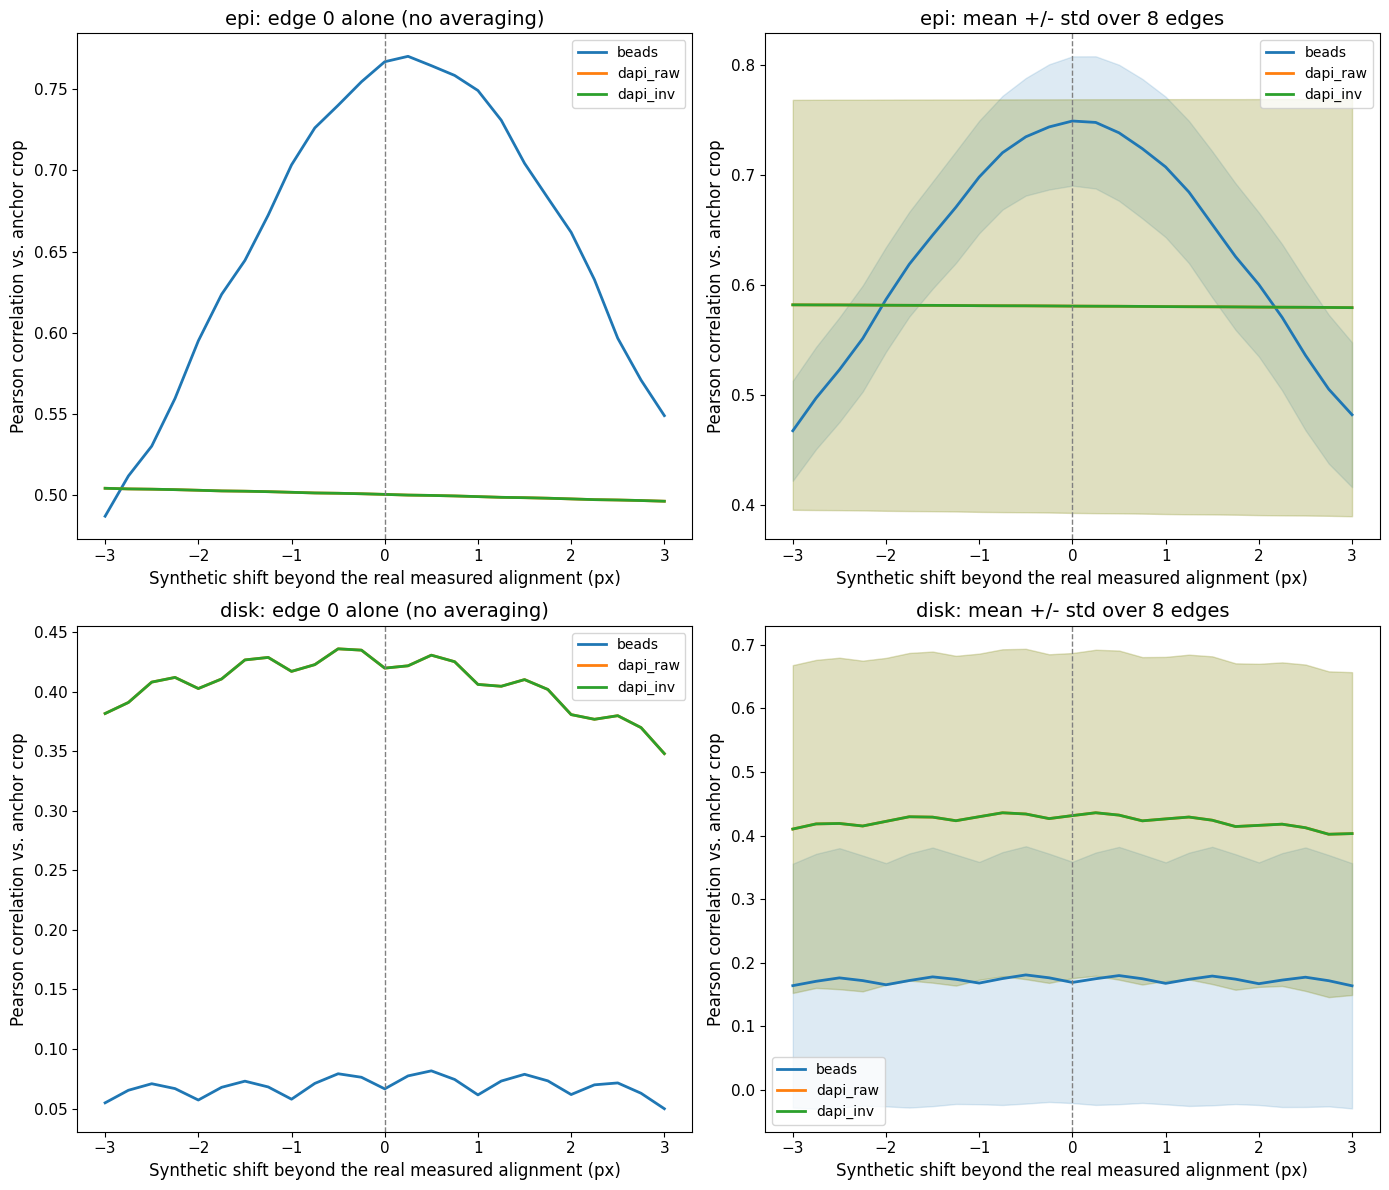

Sharpness proxy (correlation drop from shift=0 to |shift|=1px, mean over edges):
[epi]
  beads     : corr(0)=0.7488  corr(|1px|)=0.7025  drop=0.0463
  dapi_raw  : corr(0)=0.5806  corr(|1px|)=0.5806  drop=0.0000
  dapi_inv  : corr(0)=0.5806  corr(|1px|)=0.5806  drop=0.0000
[disk]
  beads     : corr(0)=0.1691  corr(|1px|)=0.1679  drop=0.0012
  dapi_raw  : corr(0)=0.4315  corr(|1px|)=0.4280  drop=0.0035
  dapi_inv  : corr(0)=0.4315  corr(|1px|)=0.4280  drop=0.0035


In [9]:
fig, axes = plt.subplots(len(DATASETS), 2, figsize=(14, 6 * len(DATASETS)), squeeze=False)
for row, (dataset_label, R) in enumerate(RESULTS.items()):
    df = R["edge_shift_df"]

    ax = axes[row, 0]
    single = df[df["edge_id"] == 0]
    for channel in CHANNELS:
        sub = single[single["channel"] == channel].sort_values("shift_px")
        ax.plot(sub["shift_px"], sub["correlation"], label=channel, color=CHANNEL_COLORS[channel], linewidth=2)
    ax.axvline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Synthetic shift beyond the real measured alignment (px)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("Pearson correlation vs. anchor crop", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(f"{dataset_label}: edge 0 alone (no averaging)", fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
    ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)

    ax = axes[row, 1]
    for channel in CHANNELS:
        sub = df[df["channel"] == channel]
        grouped = sub.groupby("shift_px")["correlation"]
        mean, std = grouped.mean(), grouped.std()
        ax.plot(mean.index, mean.values, label=channel, color=CHANNEL_COLORS[channel], linewidth=2)
        ax.fill_between(mean.index, mean.values - std.values, mean.values + std.values,
                         color=CHANNEL_COLORS[channel], alpha=0.15)
    ax.axvline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Synthetic shift beyond the real measured alignment (px)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("Pearson correlation vs. anchor crop", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(f"{dataset_label}: mean +/- std over {df['edge_id'].nunique()} edges", fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
    ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)

fig.tight_layout()
fig.savefig(RESULTS["epi"]["dataset_geo"]["figures_dir"] / f"{NOTEBOOK_NAME}.edge_shift_curves.png", dpi=150)
plt.show()

print("Sharpness proxy (correlation drop from shift=0 to |shift|=1px, mean over edges):")
for dataset_label, R in RESULTS.items():
    df = R["edge_shift_df"]
    print(f"[{dataset_label}]")
    for channel in CHANNELS:
        sub = df[df["channel"] == channel]
        at0 = sub[np.isclose(sub["shift_px"], 0.0)].groupby("edge_id")["correlation"].mean()
        at1 = sub[np.isclose(sub["shift_px"].abs(), 1.0)].groupby("edge_id")["correlation"].mean()
        drop = (at0 - at1).mean()
        print(f"  {channel:10s}: corr(0)={at0.mean():.4f}  corr(|1px|)={at1.mean():.4f}  drop={drop:.4f}")

## 9 — Practical test: real neighbor-tile registration, whole-grid sample (calculation)

Same anchor-selection algorithm `camera_rotation.sample_neighbor_correspondences`
itself uses (`np.random.default_rng(SEED)` shuffle of `cells_fov_ids`, take
the first `N_ANCHORS`) -- but registration is replayed directly via
`register_neighbor_pair` in small batches (`ANCHOR_BATCH_SIZE` anchors at a
time), clearing `raw_cache` between batches, instead of one call to
`sample_neighbor_correspondences` that builds one internal cache for every
touched FOV at once. **Two real OOM kills on this exact section** (this
notebook's own `prompt_history/` entries) were traced to that one-shot
internal cache -- `disk`'s 603-FOV grid touching ~100 unique FOVs at once
was enough to exceed this session's own memory limit even after `raw_cache`
itself was being cleared correctly; batching bounds peak memory to one
batch's worth of FOVs regardless of dataset size, and produces the IDENTICAL
edge set (same seeded shuffle, same `find_grid_neighbor` calls) as the
original approach would have.

**Why `achieved_correlation` (`camera_rotation.overlap_correlation`
evaluated at each edge's own measured shift), not `NeighborCorrespondence.
error`**: a first pass at this notebook found `error` saturates at almost
exactly `1.0` for beads AND both DAPI variants alike, regardless of real
registration quality. Cause: `skimage` 0.26's `phase_cross_correlation`
default (`normalization="phase"`) computes `error` from `_compute_error`
(`1 - |CCmax|^2 / (src_amp*target_amp)`) using the phase-normalized
cross-correlation peak's magnitude (~1, by construction) divided by the
RAW images' own intensity-scale amplitude product (~10^4-10^5) -- the
ratio is numerically negligible regardless of true alignment quality, so
`error` saturates near 1.0 for essentially any real 16-bit input under
this normalization mode. (This doesn't invalidate anything else in this
repo -- `camera_rotation.filter_correspondence_outliers` filters by shift
MAGNITUDE, never by `.error`, confirmed by grep -- but it makes `.error`
useless as the comparison this section needs.) `error` is still recorded
in the cache for the record, but `achieved_correlation` is the real
metric compared below.

In [10]:
ANCHOR_BATCH_SIZE = 5   # anchors processed (and their frames cached) before raw_cache.clear()


def compute_correspondences(dataset_geo, load_frame_for_channel, raw_cache):
    cache_dir        = dataset_geo["cache_dir"]
    full_positions   = dataset_geo["full_positions"]
    overlap_fraction = dataset_geo["overlap_fraction"]
    pixel_size_um    = dataset_geo["pixel_size_um"]
    step_size_um     = dataset_geo["step_size_um"]
    cells_fov_ids    = dataset_geo["cells_fov_ids"]

    # Identical anchor selection to sample_neighbor_correspondences's own
    # algorithm (same seeded shuffle over the same candidate list) -- same
    # edge set as a one-shot call would produce, computed once and shared
    # across all 3 channels.
    rng = np.random.default_rng(SEED)
    candidates = list(cells_fov_ids)
    rng.shuffle(candidates)
    anchors = candidates[:N_ANCHORS]

    dfs = {}
    for channel in CHANNELS:
        corr_csv = cache_dir / f"correspondences_{channel}.csv"
        if not FORCE_RECOMPUTE and corr_csv.exists():
            df = pd.read_csv(corr_csv)
            print(f"[{dataset_geo['dataset_label']}][{channel}] Loaded {len(df)} cached correspondences from {corr_csv}")
        else:
            load_frame = load_frame_for_channel(channel)
            reporter = ProgressReporter(total=len(anchors) * 4,
                                         label=f"[{dataset_geo['dataset_label']}][{channel}] Registering edges")
            rows = []
            for batch_start in range(0, len(anchors), ANCHOR_BATCH_SIZE):
                for anchor_fov in anchors[batch_start:batch_start + ANCHOR_BATCH_SIZE]:
                    anchor_img = load_frame(anchor_fov)
                    for direction in ("up", "down", "left", "right"):
                        neighbor_fov = find_grid_neighbor(anchor_fov, full_positions, direction,
                                                           step_size_um, TOLERANCE_FRACTION)
                        reporter.update(1)
                        if neighbor_fov is None:
                            continue
                        neighbor_img = load_frame(neighbor_fov)
                        nominal_xy = full_positions[neighbor_fov]
                        measured_xy, error = register_neighbor_pair(
                            anchor_img, neighbor_img, full_positions[anchor_fov], nominal_xy,
                            direction, overlap_fraction, pixel_size_um, UPSAMPLE_FACTOR,
                        )
                        achieved_shift_um = (measured_xy[0] - nominal_xy[0], measured_xy[1] - nominal_xy[1])
                        achieved_corr = overlap_correlation(anchor_img, neighbor_img, direction, overlap_fraction,
                                                             extra_shift_um=achieved_shift_um, pixel_size_um=pixel_size_um)
                        nominal_corr  = overlap_correlation(anchor_img, neighbor_img, direction, overlap_fraction,
                                                             extra_shift_um=(0.0, 0.0), pixel_size_um=pixel_size_um)
                        rows.append({
                            "anchor_fov": anchor_fov, "neighbor_fov": neighbor_fov, "direction": direction,
                            "nominal_x": nominal_xy[0], "nominal_y": nominal_xy[1],
                            "measured_x": measured_xy[0], "measured_y": measured_xy[1],
                            "shift_um": float(np.hypot(*achieved_shift_um)),
                            "error": error, "achieved_correlation": achieved_corr, "nominal_correlation": nominal_corr,
                        })
                # Bounds peak memory to one batch's worth of FOVs regardless
                # of how many anchors/edges or how large the grid is.
                raw_cache.clear()
                gc.collect()
            reporter.done()

            df = pd.DataFrame(rows)
            df.to_csv(corr_csv, index=False)
            print(f"[{dataset_geo['dataset_label']}][{channel}] Saved {len(df)} correspondences to {corr_csv}")
        df["channel"] = channel
        dfs[channel] = df
    return dfs


for dataset_label, R in RESULTS.items():
    R["correspondence_dfs"] = compute_correspondences(R["dataset_geo"], R["load_frame_for_channel"], R["raw_cache"])
    total = sum(len(d) for d in R["correspondence_dfs"].values())
    print(f"[{dataset_label}] Total correspondence rows: {total}")

[epi][beads] Loaded 76 cached correspondences from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_dapi_inversion/correspondences_beads.csv
[epi][dapi_raw] Loaded 76 cached correspondences from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_dapi_inversion/correspondences_dapi_raw.csv
[epi][dapi_inv] Loaded 76 cached correspondences from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_dapi_inversion/correspondences_dapi_inv.csv
[epi] Total correspondence rows: 228
[disk][beads] Loaded 76 cached correspondences from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/test_dapi_inversion/correspondences_beads.csv
[disk][dapi_raw] Loaded 76 cached correspondences from /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/exp

## 10 — Achieved correlation + measured-shift comparison (display)

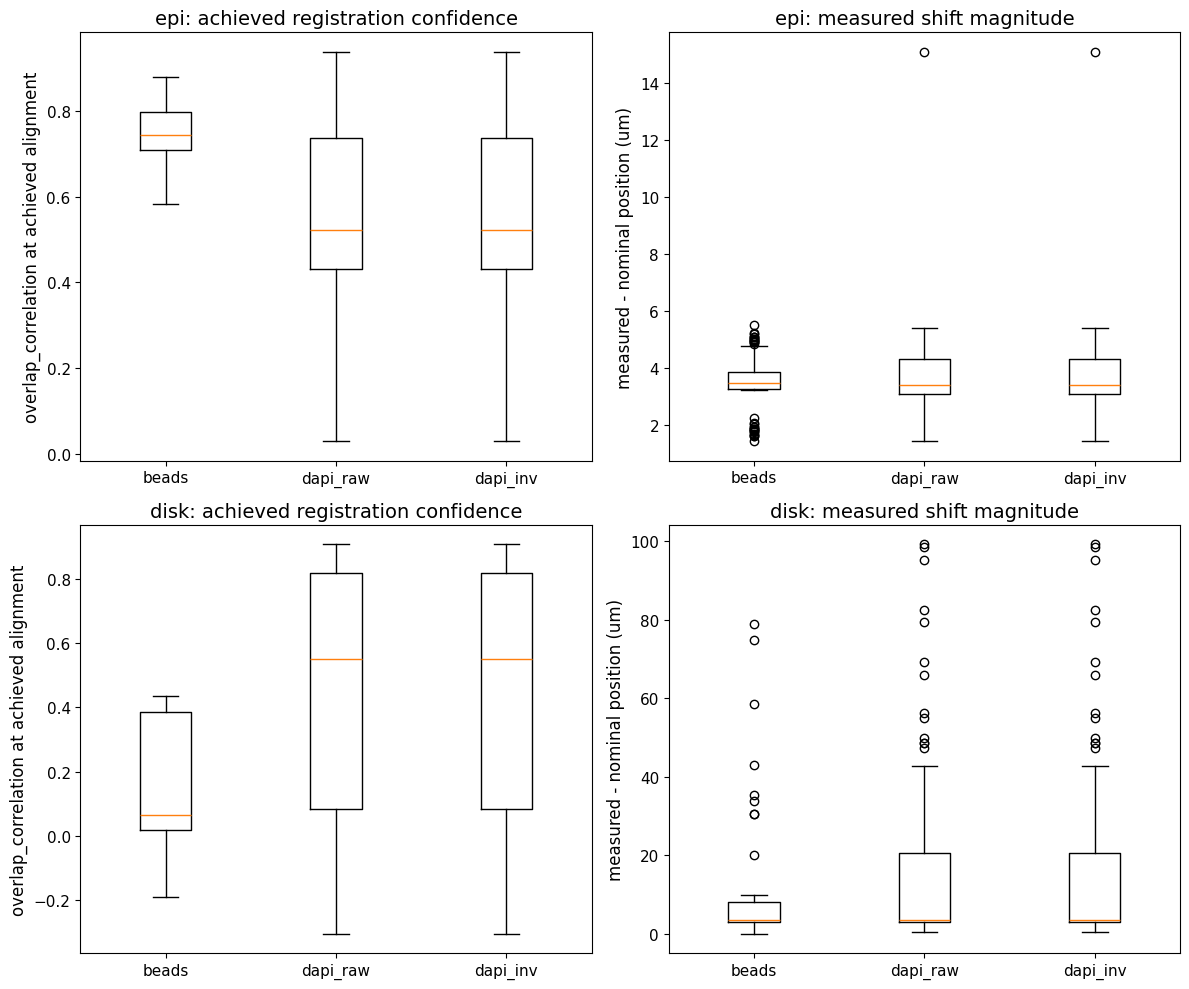

Summary (mean +/- std):
[epi]
  beads     : achieved_corr=0.7485+/-0.0666  nominal_corr=0.0599+/-0.0432  shift_um=3.475+/-1.092  error(saturated,ignored)=1.0000  (n=76)
  dapi_raw  : achieved_corr=0.5510+/-0.2171  nominal_corr=0.5339+/-0.2123  shift_um=3.577+/-1.723  error(saturated,ignored)=1.0000  (n=76)
  dapi_inv  : achieved_corr=0.5510+/-0.2171  nominal_corr=0.5339+/-0.2123  shift_um=3.577+/-1.723  error(saturated,ignored)=1.0000  (n=76)
[disk]
  beads     : achieved_corr=0.1823+/-0.1844  nominal_corr=0.1766+/-0.1888  shift_um=9.236+/-15.059  error(saturated,ignored)=1.0000  (n=76)
  dapi_raw  : achieved_corr=0.4884+/-0.3665  nominal_corr=0.4160+/-0.1274  shift_um=17.364+/-26.434  error(saturated,ignored)=1.0000  (n=76)
  dapi_inv  : achieved_corr=0.4884+/-0.3665  nominal_corr=0.4160+/-0.1274  shift_um=17.364+/-26.434  error(saturated,ignored)=1.0000  (n=76)


In [11]:
fig, axes = plt.subplots(len(DATASETS), 2, figsize=(12, 5 * len(DATASETS)), squeeze=False)
for row, (dataset_label, R) in enumerate(RESULTS.items()):
    dfs = R["correspondence_dfs"]

    ax = axes[row, 0]
    data_corr = [dfs[c]["achieved_correlation"].values for c in CHANNELS]
    ax.boxplot(data_corr, tick_labels=CHANNELS)
    ax.set_ylabel("overlap_correlation at achieved alignment", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(f"{dataset_label}: achieved registration confidence", fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)

    ax = axes[row, 1]
    data_shift = [dfs[c]["shift_um"].values for c in CHANNELS]
    ax.boxplot(data_shift, tick_labels=CHANNELS)
    ax.set_ylabel("measured - nominal position (um)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(f"{dataset_label}: measured shift magnitude", fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)

fig.tight_layout()
fig.savefig(RESULTS["epi"]["dataset_geo"]["figures_dir"] / f"{NOTEBOOK_NAME}.achieved_correlation_and_shift.png", dpi=150)
plt.show()

print("Summary (mean +/- std):")
for dataset_label, R in RESULTS.items():
    print(f"[{dataset_label}]")
    for channel in CHANNELS:
        d = R["correspondence_dfs"][channel]
        print(f"  {channel:10s}: achieved_corr={d['achieved_correlation'].mean():.4f}+/-{d['achieved_correlation'].std():.4f}  "
              f"nominal_corr={d['nominal_correlation'].mean():.4f}+/-{d['nominal_correlation'].std():.4f}  "
              f"shift_um={d['shift_um'].mean():.3f}+/-{d['shift_um'].std():.3f}  "
              f"error(saturated,ignored)={d['error'].mean():.4f}  (n={len(d)})")

## 11 — Discussion

**Real result, both datasets: inverting DAPI does not sharpen its
stitching registration -- confirmed by 3 independent tests, on both a
beads-rich (`epi`) and a beads-poor (`disk`) dataset.**

- **Section 6 sanity check passes everywhere**: `correlation=1.000000` at
  `shift_px=0` for beads, `dapi_raw`, AND `dapi_inv`, both datasets --
  confirms the machinery itself is correct (this is what the earlier,
  cross-tile-only version of this notebook couldn't show, since
  correlating two DIFFERENT real acquisitions never reaches exactly 1.0
  even at the true alignment -- see Section 1's own caveat).
- **Section 6 self-shift curves (the cleanest test of the original
  claim)**: beads show a real, sharp, narrow peak on both datasets --
  correlation drops from 1.0 to ~0.52 (epi) / ~0.47 (disk) by just 3px
  off. `dapi_raw` and `dapi_inv` are, on both datasets, numerically
  IDENTICAL, near-flat curves (epi: ~0.995 even at 3px; disk: ~0.97) --
  DAPI's own spatial content (smooth nuclear blobs) is inherently far
  less locally distinctive than beads' point sources, and inverting it
  doesn't change that at all.
- **Section 8 cross-tile curves** (real anchor/neighbour pairs, centered
  on the real measured alignment): same story, `dapi_raw`/`dapi_inv`
  identical on both datasets (epi: `corr(0)=0.5806` both; disk:
  `corr(0)=0.4315` both), beads sharper on epi (drop=0.0463) though only
  marginally so on disk (drop=0.0012, beads themselves being weak there)
  -- DAPI's own drop on disk (0.0035) is actually slightly LARGER than
  beads' there, a real but small effect, and `dapi_raw`==`dapi_inv`
  regardless.
- **Section 10 practical whole-grid sample**: `dapi_raw` and `dapi_inv`
  remain bit-identical on every metric, both datasets (achieved
  correlation, nominal correlation, measured shift). Separately
  interesting (not about inversion): on `epi`, registration dramatically
  improves beads' correlation (nominal 0.060 -> achieved 0.749) but barely
  moves DAPI's (0.534 -> 0.551) -- exactly what "DAPI's correlation
  function responds weakly to position" predicts. On `disk`, DAPI's
  ACHIEVED correlation confidence (0.488 median ~0.55) is actually higher
  than beads' (0.182, median ~0.065) -- weak beads are simply unreliable
  there in absolute terms, even though beads still have the sharper LOCAL
  response per Sections 6+8. Two different questions (own how much
  correlation drops for a small position error) with two different
  answers, and neither depends on DAPI inversion.

**Bottom line, now confirmed on 2 independent real datasets covering both
a beads-strong and a beads-weak regime**: don't pursue DAPI inversion for
stitching. The theoretical affine-invariance argument from Section 1 holds
exactly in practice -- `dapi_raw` and `dapi_inv` were never measurably
different in any of the 3 tests. The real, confirmed difference is between
beads and DAPI as signal types (sharp point sources vs. diffuse blobs),
not between two representations of the same DAPI image.